In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [14]:
df = pd.read_csv("research_centers.csv")

df.head()

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983


In [15]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   researchCenterId         50 non-null     object 
 1   researchCenterName       50 non-null     object 
 2   city                     50 non-null     object 
 3   latitude                 50 non-null     float64
 4   longitude                50 non-null     float64
 5   internalFacilitiesCount  50 non-null     int64  
 6   hospitals_10km           50 non-null     int64  
 7   pharmacies_10km          50 non-null     int64  
 8   facilityDiversity_10km   50 non-null     float64
 9   facilityDensity_10km     50 non-null     float64
dtypes: float64(4), int64(3), object(3)
memory usage: 4.0+ KB


researchCenterId           0
researchCenterName         0
city                       0
latitude                   0
longitude                  0
internalFacilitiesCount    0
hospitals_10km             0
pharmacies_10km            0
facilityDiversity_10km     0
facilityDensity_10km       0
dtype: int64

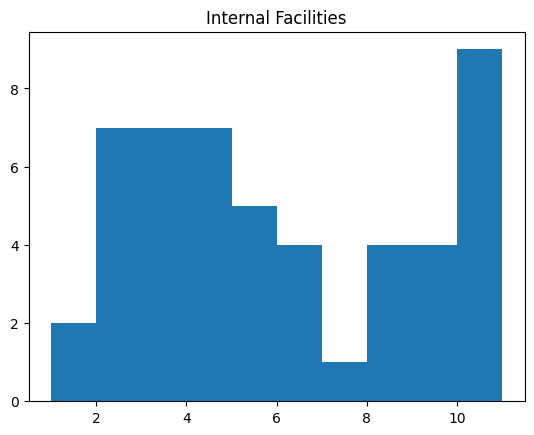

In [16]:
plt.hist(df["internalFacilitiesCount"])
plt.title("Internal Facilities")
plt.show()

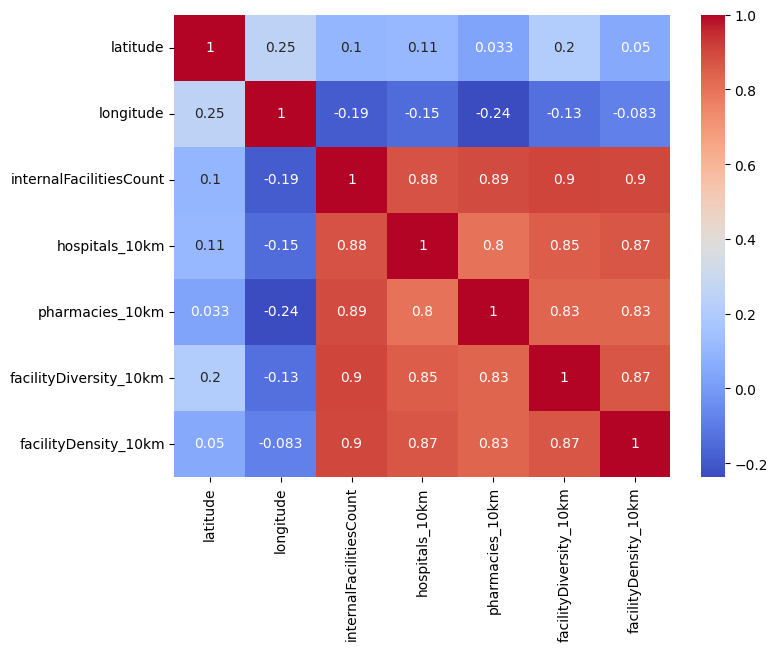

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=["float64","int64"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [18]:
features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km",
]

X = df[features]

In [19]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [20]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

In [21]:
score = silhouette_score(X_scaled, clusters)

score

0.5519201011808984

In [22]:
df.groupby("cluster")[features].mean()

,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
cluster,,,,,
0,4.941176,1.529412,2.058824,0.559935,0.289845
1,9.529412,3.470588,4.117647,0.850424,0.536852
2,2.312500,0.500000,0.437500,0.279126,0.125271


In [23]:
summary = df.groupby("cluster")[features].mean()

order = summary.mean(axis=1).sort_values(ascending=False).index

mapping = {
    order[0]: "Premium",
    order[1]: "Standard",
    order[2]: "Basic",
}

df["qualityTier"] = df["cluster"].map(mapping)

df.head()

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km,cluster,qualityTier
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506,2,Basic
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965,2,Basic
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155,2,Basic
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016,1,Premium
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983,1,Premium
